# **G345 - ANÁLISIS DE DATOS**

# **ANÁLISIS DE LA DEPRESIÓN EN ESTUDIANTES Y SUS PREDICTORES**

# **Preparar el Entorno**

In [ ]:
# Se habilita el Drive para la carga de archivos
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Se importan las librerías
import numpy as np
import pandas as pd
import os

import matplotlib.pyplot as plt   # Visualizaciones
import seaborn as sns             # Visualizaciones
import statsmodels.api as sm      # Funciones Modelos Estadísticos

# **Cargar Datos desde un CSV**

### **Acerca de este archivo**

Este conjunto de datos contiene información completa sobre la salud mental y sus factores relacionados, de un conjunto de estudiantes de diferentes niveles académicos en varias ciudades de la India. Está diseñado para analizar **las tendencias y los predictores de la depresión** en estudiantes.

Los datos incluyen información demográfica, presiones académicas y laborales, hábitos de vida e indicadores específicos de salud mental.

Los investigadores pueden utilizar este conjunto de datos para identificar factores de riesgo de depresión y desarrollar estrategias de intervención temprana, garantizando al mismo tiempo el manejo ético de información confidencial.

### **Esquema del CSV: Diccionario de Datos**



**Id:**
Un identificador único asignado a cada registro de estudiante en el conjunto de datos.

**Género:**
El género del estudiante (p. ej., masculino, femenino, otro). Esto ayuda a analizar las tendencias específicas de género en salud mental.

**Edad:**
La edad del estudiante en años.

**Ciudad:**
La ciudad o región donde reside el estudiante, que proporciona el contexto geográfico para el análisis.

**Presión Académica:**
Una medida que indica el nivel de presión que enfrenta el estudiante en el ámbito académico. Esto podría incluir el estrés por exámenes, tareas y expectativas académicas generales.

**Presión Laboral:**
Una medida de la presión relacionada con el trabajo o las responsabilidades laborales, relevante para estudiantes que trabajan mientras estudian.

**Promedio de Calificaciones Acumulativo:**
El promedio de calificaciones acumulativo del estudiante, que refleja su rendimiento académico general.

**Satisfacción con los Estudios:**
Un indicador de la satisfacción del estudiante con sus estudios, que puede correlacionarse con el bienestar mental.

**Satisfacción Laboral:**
Una medida de la satisfacción del estudiante con su trabajo o entorno laboral, si corresponde.

**Duración del Sueño:**
El promedio de horas que el estudiante duerme al día, un factor importante para la salud mental.

**Hábitos Alimenticios:**
Una evaluación de los patrones de alimentación y los hábitos nutricionales del estudiante, que pueden afectar su salud general y estado de ánimo.

**Título:**
El título o programa académico que cursa el estudiante.

**¿Ha tenido alguna vez pensamientos suicidas?:**
Un indicador binario (Sí/No) que refleja si el estudiante alguna vez ha experimentado ideación suicida.

**Horas de trabajo/Estudio:**
El promedio de horas diarias que el estudiante dedica al trabajo o al estudio, lo cual puede influir en sus niveles de estrés.

**Estrés Financiero:**
Una medida del estrés experimentado debido a preocupaciones financieras, que puede afectar la salud mental.

**Antecedentes Familiares de Enfermedades Mentales:**
Indica si existen antecedentes familiares de enfermedades mentales (Sí/No), lo cual puede ser un factor significativo en la predisposición a la salud mental.

**Depresión:**
La variable objetivo que indica si el estudiante experimenta depresión (Sí/No). Este es el enfoque principal del análisis.


### **Archivo CSV**

In [ ]:
# Lectura del archivo .csv

ruta_csv = '/content/drive/MyDrive/Análisis G345/Sesión 17 - Feb 02 Lun/Dataset Preparado.csv'

try:
  df = pd.read_csv(ruta_csv)
except OSError as err:
  print(f"No se pudo abrir el archivo. Error: {err}.")
else:
  print(f"Archivo cargado con éxito en el dataframe.")

Archivo cargado con éxito en el dataframe.


In [ ]:
df.head()

,Género,Edad,Ciudad,Presión Académica,Presión Laboral,Promedio Calificaciones Acumulativo,Satisfacción con el Estudio,Satisfacción Laboral,Duración del Sueño,Hábitos Alimenticios,...,Estrés Financiero,Antecedentes Familiares de Enfermedades Mentales,Depresión,GEN,CIU,DS,HA,TIT,PS,AFEM
0,Masculino,33,Visakhapatnam,5,0,8.97,2,0,5-6 horas,Saludable,...,0,No,1,0,0,1,2,0,1,0
1,Femenino,24,Bangalore,2,0,5.90,5,0,5-6 horas,Moderado,...,1,Si,0,1,1,1,1,1,0,1
2,Masculino,31,Srinagar,3,0,7.03,5,0,Menos de 5 horas,Saludable,...,0,Si,0,0,2,0,2,2,0,1
3,Femenino,28,Varanasi,3,0,5.59,2,0,7-8 horas,Moderado,...,4,Si,1,1,3,2,1,3,1,1
4,Femenino,25,Jaipur,4,0,8.13,3,0,5-6 horas,Moderado,...,0,No,0,1,4,1,1,4,1,0




---



---


#**Análisis Bivariado**

## **Tabla de Frecuencias**

### **Para Tablas de Contingencia o Frecuencias Cruzadas (crosstab())**

Las Tablas de Contingencia (o Frecuencias Cruzadas) son tablas que muestran la distribución conjunta de dos o más variables categóricas.

En pandas, la función **pd.crosstab()** se utiliza para crear este tipo de tablas, contando las frecuencias de combinaciones entre categorías.

**¿Qué hace pd.crosstab()?**

Agrupa los datos y cuenta cuántas veces aparecen combinaciones específicas de valores categóricos. Es similar a una tabla dinámica (pivot table) enfocada en frecuencias.

**Parámetros clave:**
*  margins: Si es True, añade subtotales (filas y columnas "Total").
*  normalize: Si es True, calcula proporciones en lugar de conteos; si es 'index' muestra el porcentaje por fila de cada cruce.

In [ ]:
# Entre dos variables categóricas

# Género vs Depresión con totales
pd.crosstab(df['Género'], df['Depresión'], margins=True)

Depresión,0,1,All
Género,,,
Femenino,5128,7215,12343
Masculino,6426,9111,15537
All,11554,16326,27880


In [ ]:
# Género vs Depresión
tab_contingencia = pd.crosstab(df['Género'], df['Depresión'])
tab_contingencia

Depresión,0,1
Género,,
Femenino,5128,7215
Masculino,6426,9111


In [ ]:
# Con porcentajes por fila
pd.crosstab(df['Género'], df['Depresión'], normalize='index').round(2)

Depresión,0,1
Género,,
Femenino,0.42,0.58
Masculino,0.41,0.59


In [ ]:
# Con proporciones por cada cruce
pd.crosstab(df['Género'], df['Depresión'], normalize=True).round(2)

Depresión,0,1
Género,,
Femenino,0.18,0.26
Masculino,0.23,0.33


In [ ]:
# Tabla múltiple (3 variables)

pd.crosstab([df['Género'], df['Depresión']], df['Pensamientos Suicidas?'], margins=True, margins_name="Total")

Pensamientos Suicidas?     No     Si  Total
Género    Depresión                        
Femenino  0              3503   1625   5128
          1              1020   6195   7215
Masculino 0              4355   2071   6426
          1              1357   7754   9111
Total                   10235  17645  27880

### **Para Frecuencias con Agregación (pivot_table())**

La función **pivot_table()** en pandas permite crear tablas dinámicas (pivot tables) que resumen datos mediante agregaciones como conteos, sumas, promedios, etc., en función de dos o más variables categóricas. A diferencia de crosstab() que solo cuenta frecuencias, pivot_table() es más flexible y puede aplicar múltiples operaciones estadísticas.

**¿Cuándo usar pivot_table()?**
  *  Cuando necesitas agregar datos (no solo contar frecuencias).
  *  Para analizar relaciones entre variables categóricas con métricas como: Conteo (count), Suma (sum), Promedio (mean), Mediana (median), etc.
  *  Cuando trabajas con datos numéricos y quieres resumirlos por categorías.

In [ ]:
df.pivot_table(index=df['Género'],
    columns=df['Depresión'],
    aggfunc='mean',    # Función de agregación (ej: 'sum', 'count') (size cuenta ocurrencias)
                        # Las funciones de agregación que hacen operaciones numéricas sólo deben aplicarse si la columna referenciada en 'values' es numérica
    values='Edad',      # Columna a la que se le aplicará la función aggfunc
    fill_value=0,       # Valor para reemplazar NaN
    margins=False,      # Si incluye totales (como en crosstab)
    margins_name='All'  # Nombre de la fila/columna de totales
)

Depresión,0,1
Género,,
Femenino,27.042122,24.867360
Masculino,27.221444,24.901767


In [ ]:
# Para resumir el 'Promedio Calificaciones Acumulativo' por categorías como 'Género' y 'Depresión'
# usando pivot_table, se puede hacer lo siguiente:

df.pivot_table(index=df['Género'],
    columns=df['Depresión'],
    aggfunc='mean',
    values='Promedio Calificaciones Acumulativo',
    fill_value=0,
    margins=False,
    margins_name='All'
)

Depresión,0,1
Género,,
Femenino,7.539741,7.638049
Masculino,7.679804,7.719471


### **Alternativa Flexible (groupby() + size())**

Esta alternativa realiza varias acciones al tiempo:

`df.groupby(['Género', 'Título'])`: Agrupa el DataFrame por las columnas 'Género' y 'Título', creando una estructura jerárquica (multiíndice).

`.size()`: Cuenta el número de filas (ocurrencias) para cada combinación única de Género y Título. Retorna una Serie con un MultiIndex (Género y Título) y los conteos como valores.

`.unstack()`: "Desapila" el nivel 'Título' del MultiIndex, convirtiendo los valores únicos de 'Título' en columnas. Los Géneros quedan como filas, y los conteos como valores de la tabla.

`fill_value=0`: Asegura que las combinaciones sin datos muestren 0 (en lugar de NaN).

In [ ]:
df.groupby(['Género', 'Título']).size()

Género     Título                                    
Femenino   12º Grado Educación Secundaria                2705
           Doctor en Medicina                             202
           Doctorado                                      256
           Licenciatura en Administración de Empresas     331
           Licenciatura en Aplicaciones Informáticas      610
           Licenciatura en Arquitectura                   729
           Licenciatura en Artes/Humanidades              304
           Licenciatura en Ciencias                       388
           Licenciatura en Comercio                       665
           Licenciatura en Derecho                        292
           Licenciatura en Educación                      954
           Licenciatura en Farmacia                       204
           Licenciatura en Gestión Hotelera               586
           Licenciatura en Ingeniería                     108
           Licenciatura en Medicina y Cirugía             127
           Licenciatura en Tecnología                     386
           Maestría en Administración de Empresas         267
           Maestría en Aplicaciones Informáticas          455
           Maestría en Artes/Humanidades                  233
           Maestría en Ciencias                           478
           Maestría en Comercio                           312
           Maestría en Derecho                            218
           Maestría en Educación                          340
           Maestría en Farmacia                           372
           Maestría en Gestión Hotelera                    96
           Maestría en Ingeniería                          89
           Maestría en Medicina y Cirugía                 224
           Maestría en Tecnología                         396
           Otros                                           16
Masculino  12º Grado Educación Secundaria                3375
           Doctor en Medicina                             370
           Doctorado                                      264
           Licenciatura en Administración de Empresas     365
           Licenciatura en Aplicaciones Informáticas      822
           Licenciatura en Arquitectura                   747
           Licenciatura en Artes/Humanidades              293
           Licenciatura en Ciencias                       499
           Licenciatura en Comercio                       840
           Licenciatura en Derecho                        379
           Licenciatura en Educación                     1301
           Licenciatura en Farmacia                       266
           Licenciatura en Gestión Hotelera               339
           Licenciatura en Ingeniería                     113
           Licenciatura en Medicina y Cirugía             134
           Licenciatura en Tecnología                     766
           Maestría en Administración de Empresas         294
           Maestría en Aplicaciones Informáticas          588
           Maestría en Artes/Humanidades                  311
           Maestría en Ciencias                           711
           Maestría en Comercio                           422
           Maestría en Derecho                            264
           Maestría en Educación                          480
           Maestría en Farmacia                           550
           Maestría en Gestión Hotelera                    95
           Maestría en Ingeniería                          96
           Maestría en Medicina y Cirugía                 210
           Maestría en Tecnología                         624
           Otros                                           19
dtype: int64

In [ ]:
df.groupby(['Género', 'Título']).size().unstack(fill_value=0)

Título,12º Grado Educación Secundaria,Doctor en Medicina,Doctorado,Licenciatura en Administración de Empresas,Licenciatura en Aplicaciones Informáticas,Licenciatura en Arquitectura,Licenciatura en Artes/Humanidades,Licenciatura en Ciencias,Licenciatura en Comercio,Licenciatura en Derecho,...,Maestría en Ciencias,Maestría en Comercio,Maestría en Derecho,Maestría en Educación,Maestría en Farmacia,Maestría en Gestión Hotelera,Maestría en Ingeniería,Maestría en Medicina y Cirugía,Maestría en Tecnología,Otros
Género,,,,,,,,,,,,,,,,,,,,,
Femenino,2705,202,256,331,610,729,304,388,665,292,...,478,312,218,340,372,96,89,224,396,16
Masculino,3375,370,264,365,822,747,293,499,840,379,...,711,422,264,480,550,95,96,210,624,19


## **Analizar Coeficiente de Correlación**

Los coeficientes de correlación miden la relación estadística entre dos variables, pero cada método (pearson, spearman, kendall) tiene sus propias suposiciones y casos de uso.

### **🔍 1. Correlación de Pearson (r)**

**Interpretación:**

Mide la relación lineal entre dos variables continuas.

**Rango de valores: -1 a 1.**

*   1: Correlación positiva perfecta.
*   -1: Correlación negativa perfecta.
*   0: No hay correlación lineal.

**Supuestos:**

*   Las variables deben tener una distribución normal (o aproximadamente normal).
*   La relación debe ser lineal.

**Ejemplo de uso:**

*   Relación entre altura y peso en personas.
*   Relación entre temperatura y consumo de energía.


### **📉 2. Correlación de Spearman (ρ)**

**Interpretación:**
*   Mide la relación monótona (no necesariamente lineal).
*   No requiere normalidad (es no paramétrica).
*   Usa rangos en lugar de valores brutos.

**Rango de valores:** -1 a 1 (igual que Pearson).

**Casos de uso:**
*   Datos no normales.
*   Datos ordinales (ej: encuestas con escalas Likert).
*   Relaciones no lineales pero monótonas (ej: exponenciales).

**Ejemplo de Uso:**
*   Datos ordinales (relaciones entre resultados de encuestas)
*   Relación entre la edad y el riesgo de enfermedades en personas.

### **🔄 3. Correlación de Kendall (τ)**

**Interpretación:**
*   Similar a Spearman, pero más robusta para datos con muchos empates o muestras pequeñas.
*   Mide la concordancia entre rangos.

**Rango de valores:** -1 a 1.

**Casos de uso:**
*   Datos ordinales con empates o no normales
*   Pequeños conjuntos de datos

**Ejemplo de Uso:**
*   Rankings con empates
*   Relación entre la experiencia y el salario de personas

### **⚠️ Errores comunes al interpretar las correlaciones**

**Confundir correlación con causalidad:** Que dos variables estén correlacionadas no significa necesariamente que una cause la otra.

**Ignorar no linealidades:** Pearson puede subestimar relaciones no lineales (usar Spearman en esos casos).

**Usar Pearson con datos ordinales:** Para escalas Likert, siempre usa Spearman o Kendall.

### **Se calcularán los 3 coeficientes para comparar los resultados:**

In [ ]:
# Extraigo las columnas numéricas que soportan el cálculo de Pearson (continuas y continuas discretas)
df_continuos = df[['Edad','Promedio Calificaciones Acumulativo','Horas de Trabajo']]

In [ ]:
# Mostrar la matriz de correlaciones de Pearson entre las variables continuas del DataFrame

corr_p = df_continuos.corr( method='pearson',  # Método de correlación: 'pearson': Correlación lineal estándar (para datos normalmente distribuidos). 'kendall': Correlación de rangos de Kendall (para datos ordinales o no normales).
                                     # 'spearman': Correlación de rangos de Spearman (no paramétrica).
                min_periods=1,       # Número mínimo de observaciones requeridas para calcular la correlación. Si hay menos de min_periods valores no nulos en una pareja de columnas, el resultado será NaN. (1 por Defecto)
                numeric_only=True)   # Si True, solo incluye columnas numéricas en el cálculo. Si False (default), intenta convertir columnas no numéricas a tipo numérico antes de calcular.
corr_p

,Edad,Promedio Calificaciones Acumulativo,Horas de Trabajo
Edad,1.000000,0.005012,-0.032912
Promedio Calificaciones Acumulativo,0.005012,1.000000,0.002873
Horas de Trabajo,-0.032912,0.002873,1.000000


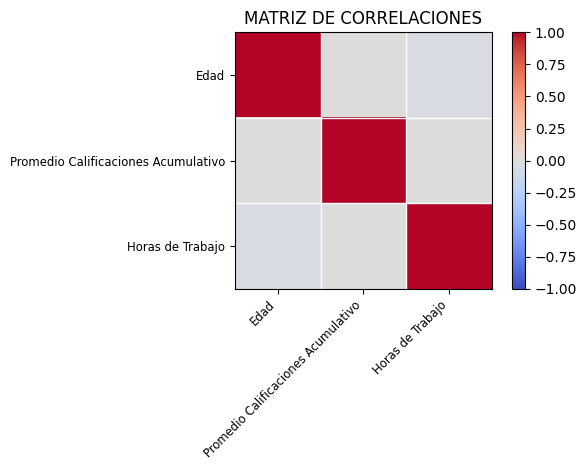

In [ ]:
# Mostrar la gráfica para visualizar la matriz de correlación en forma de heatmap (mapa de calor) utilizando la función sm.graphics.plot_corr de la librería statsmodels (sm).

sm.graphics.plot_corr(corr_p,                           # Matriz de datos (obligatorio)
                      xnames=list(corr_p.columns),        # Lista de etiquetas para los ejes *x* (columnas). Si no se especifica, se usan los nombres de las columnas de corr
                      ynames=None,                      # Lista de etiquetas para los ejes *y* (filas). Si no se especifica, se usan los mismos nombres que xnames.
                      title="MATRIZ DE CORRELACIONES",  # Título del gráfico
                      cmap="coolwarm",                  # Mapa de colores para el heatmap (por defecto: 'jet')
                      normcolor=True)                   # Si True, el rango de colores va desde -1 (correlación negativa) hasta +1 (correlación positiva).
                                                        # Si False (por defecto), el rango se normaliza entre 0 y 1.
plt.show()  # Muestra la gráfica

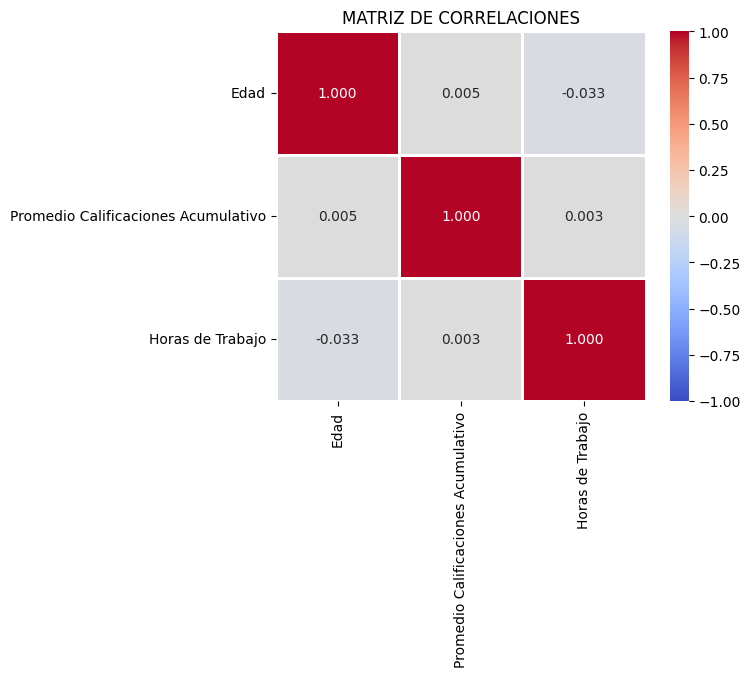

In [ ]:
# Mostrar la gráfica para visualizar la matriz de correlación en forma de heatmap (mapa de calor) utilizando la función sns.heatmap() de la librería Seaborn (sns).

sns.heatmap(
    corr_p,                           # Matriz de datos (obligatorio)
    vmin=-1,                          # Valor mínimo para la escala de colores
    vmax=1,                           # Valor máximo para la escala de colores
    cmap='coolwarm',                  # Mapa de colores (ej: 'coolwarm', 'viridis')
    center=0,                         # Centro de la divergencia de colores (para datos con valores positivos/negativos)
    annot=True,                       # Si True, muestra los valores en cada celda
    fmt='.3f',                        # Formato de los valores anotados (ej: '.1f' para 1 decimal)
    linewidths=1,                     # Ancho de las líneas entre celdas
    linecolor='white',                # Color de las líneas entre celdas
    cbar=True,                        # Si True, muestra la barra de colores (colorbar)
    square=True,                     # Si True, fuerza celdas cuadradas
    xticklabels=list(corr_p.columns),   # Etiquetas del eje X (puede ser lista o 'auto')
    yticklabels='auto',               # Etiquetas del eje Y (puede ser lista o 'auto')
    mask=None                         # Máscara para ocultar ciertas celdas (útil para matrices triangulares)
)

plt.title("MATRIZ DE CORRELACIONES")
plt.show()

In [ ]:
# Otra posibilidad de correlación es medir la relación entre una variable cuantitativa (continua o de intervalo/razón)
# y una variable dicotómica genuina (0/1). ESto se conoce como Correlación Punto-Biserial y es un tipo especial de
# correlación de Pearson. La interpretación es análoga a la de Pearson.

df_p_biserial = df[['Promedio Calificaciones Acumulativo','Depresión']]

In [ ]:
# Mostrar la matriz de correlaciones de Pearson Punto-Biserial

corr_ppb = df_p_biserial.corr( method='pearson',  # Método de correlación: 'pearson': Correlación lineal estándar (para datos normalmente distribuidos). 'kendall': Correlación de rangos de Kendall (para datos ordinales o no normales).
                                     # 'spearman': Correlación de rangos de Spearman (no paramétrica).
                min_periods=1,       # Número mínimo de observaciones requeridas para calcular la correlación. Si hay menos de min_periods valores no nulos en una pareja de columnas, el resultado será NaN. (1 por Defecto)
                numeric_only=True)   # Si True, solo incluye columnas numéricas en el cálculo. Si False (default), intenta convertir columnas no numéricas a tipo numérico antes de calcular.
corr_ppb

,Promedio Calificaciones Acumulativo,Depresión
Promedio Calificaciones Acumulativo,1.000000,0.022057
Depresión,0.022057,1.000000


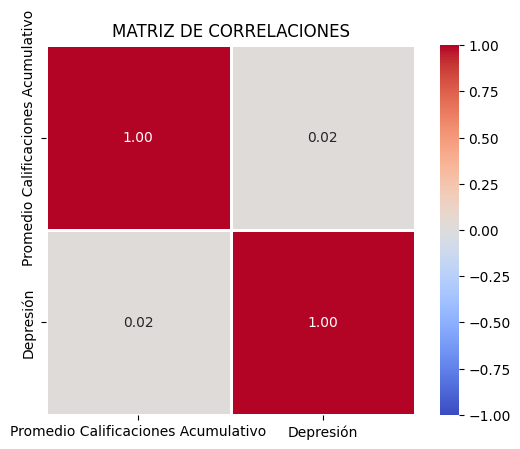

In [ ]:
# Mostrar la gráfica para visualizar la matriz de correlaciones
sns.heatmap(corr_ppb, vmin=-1, vmax=1, cmap='coolwarm', center=0, annot=True, fmt='.2f', linewidths=1, linecolor='white',
            cbar=True, square=True, xticklabels=list(corr_ppb.columns), yticklabels='auto', mask=None)
plt.title("MATRIZ DE CORRELACIONES")
plt.show()

In [ ]:
# Para calcular la correlación entre Edad (numérica discreta) y Depresión (binaria 0/1), u
# Horas de Trabajo (numérica discreta) y Depresión (binaria 0/1), se puede utilizar Pearson,
# que se interpretaría como correlación punto-biserial, o Spearman que no asume normalidad
# y usa rangos.

df_continuos_discretos = df[['Edad','Horas de Trabajo', 'Depresión']]

In [ ]:
corr_p_pb = df_continuos_discretos.corr( method='pearson', min_periods=1, numeric_only=True)   # Si True, solo incluye columnas numéricas en el cálculo. Si False (default), intenta convertir columnas no numéricas a tipo numérico antes de calcular.
corr_p_pb

,Edad,Horas de Trabajo,Depresión
Edad,1.000000,-0.032912,-0.226475
Horas de Trabajo,-0.032912,1.000000,0.208675
Depresión,-0.226475,0.208675,1.000000


In [ ]:
corr_s_p = df_continuos_discretos.corr( method='spearman', min_periods=1, numeric_only=True)
corr_s_p

,Edad,Horas de Trabajo,Depresión
Edad,1.000000,-0.029168,-0.225356
Horas de Trabajo,-0.029168,1.000000,0.200772
Depresión,-0.225356,0.200772,1.000000


In [ ]:
# Extraigo las columnas categóricas que soportan el cálculo de Spearman
df_ordinales = df[['Presión Académica', 'Presión Laboral',
       'Satisfacción con el Estudio', 'Satisfacción Laboral',
       'Estrés Financiero', 'CIU', 'DS', 'HA', 'TIT', 'Depresión']]

In [ ]:
# Mostrar la matriz de correlaciones de Spearman entre las variables del DataFrame
corr_s = df_ordinales.corr( method='spearman', min_periods=1, numeric_only=True)
corr_s

,Presión Académica,Presión Laboral,Satisfacción con el Estudio,Satisfacción Laboral,Estrés Financiero,CIU,DS,HA,TIT,Depresión
Presión Académica,1.000000,-0.018384,-0.116197,-0.021484,0.149973,0.032589,-0.043173,-0.089999,-0.050171,0.472413
Presión Laboral,-0.018384,1.000000,-0.018346,0.612361,0.000891,-0.003173,0.002625,0.005829,-0.007746,-0.005312
Satisfacción con el Estudio,-0.116197,-0.018346,1.000000,-0.019249,-0.064346,0.000304,0.012461,0.019848,-0.030252,-0.168146
Satisfacción Laboral,-0.021484,0.612361,-0.019249,1.000000,0.005710,-0.007383,-0.002262,-0.000235,-0.011046,-0.002944
Estrés Financiero,0.149973,0.000891,-0.064346,0.005710,1.000000,0.001027,-0.005348,-0.088654,-0.024436,0.362616
CIU,0.032589,-0.003173,0.000304,-0.007383,0.001027,1.000000,0.000520,0.004191,0.003806,0.024640
DS,-0.043173,0.002625,0.012461,-0.002262,-0.005348,0.000520,1.000000,-0.002236,-0.003752,-0.087313
HA,-0.089999,0.005829,0.019848,-0.000235,-0.088654,0.004191,-0.002236,1.000000,0.025520,-0.207274
TIT,-0.050171,-0.007746,-0.030252,-0.011046,-0.024436,0.003806,-0.003752,0.025520,1.000000,-0.071859
Depresión,0.472413,-0.005312,-0.168146,-0.002944,0.362616,0.024640,-0.087313,-0.207274,-0.071859,1.000000


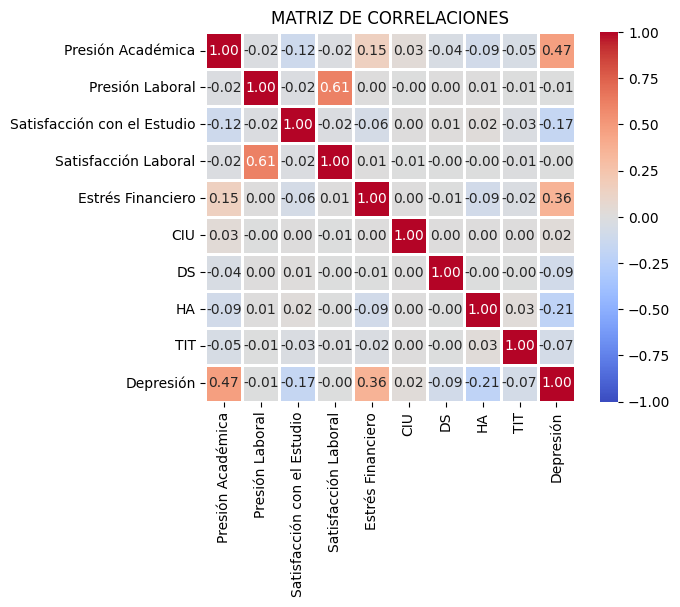

In [ ]:
# Mostrar la gráfica para visualizar la matriz de correlaciones
sns.heatmap(corr_s, vmin=-1, vmax=1, cmap='coolwarm', center=0, annot=True, fmt='.2f', linewidths=1, linecolor='white',
            cbar=True, square=True, xticklabels=list(corr_s.columns), yticklabels='auto', mask=None)
plt.title("MATRIZ DE CORRELACIONES")
plt.show()

In [ ]:
df_ordinales_empates = df[['GEN', 'PS', 'AFEM', 'Depresión']]

In [ ]:
# Mostrar la matriz de correlaciones de Kendall entre las variables del DataFrame
corr_k = df_ordinales_empates.corr( method='kendall', min_periods=1, numeric_only=True)
corr_k

,GEN,PS,AFEM,Depresión
GEN,1.000000,0.001232,0.015807,-0.001880
PS,0.001232,1.000000,0.026118,0.546275
AFEM,0.015807,0.026118,1.000000,0.053289
Depresión,-0.001880,0.546275,0.053289,1.000000


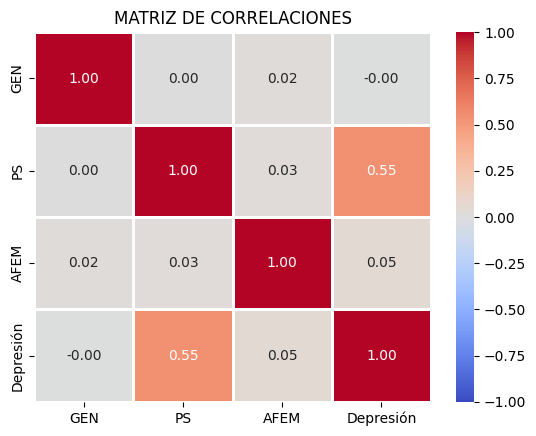

In [ ]:
# Mostrar la gráfica para visualizar la matriz de correlaciones
sns.heatmap(corr_k, vmin=-1, vmax=1, cmap='coolwarm', center=0, annot=True, fmt='.2f', linewidths=1, linecolor='white',
            cbar=True, square=False, xticklabels=list(corr_k.columns), yticklabels='auto', mask=None)
plt.title("MATRIZ DE CORRELACIONES")
plt.show()

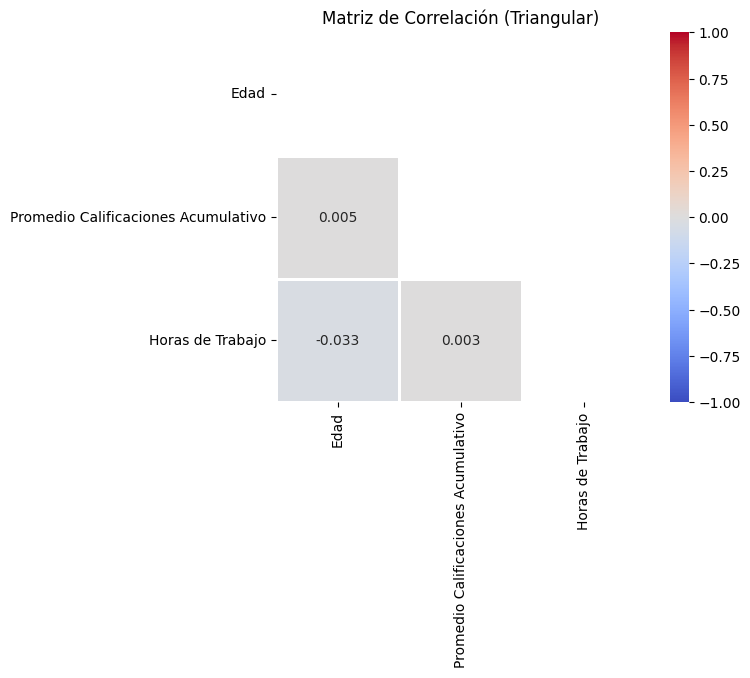

In [ ]:
# Mostrar la gráfica para visualizar la matriz de correlaciones con máscara triangular
mask = np.triu(np.ones_like(corr_p, dtype=bool))

sns.heatmap(corr_p, vmin=-1, vmax=1, cmap='coolwarm', center=0, annot=True, fmt='.3f', linewidths=1, linecolor='white',
            cbar=True, square=True, xticklabels=list(corr_p.columns), yticklabels='auto', mask=mask)
plt.title("Matriz de Correlación (Triangular)")
plt.show()

### **¿Qué es una Escala Likert?**

Una **Escala Likert** es un tipo de escala psicométrica ampliamente utilizada en encuestas y cuestionarios para medir actitudes, opiniones o percepciones. Se caracteriza por:

*  **Estructura típica:** Items con 5 a 7 puntos de respuesta
Ejemplo común:
  1. Totalmente en desacuerdo
  2. En desacuerdo
  3. Neutral
  4. De acuerdo
  5. Totalmente de acuerdo

*  **Propiedades:**
  *  **Ordinal** (los valores tienen orden jerárquico)
  *  **Discreta** (valores enteros específicos)
  *  **No equidistante** (no se asume igual distancia entre puntos)

**Mejores métodos de análisis para variables Likert**

1. **Estadísticos descriptivos adecuados:**
  *  **Moda:** Valor más frecuente
  *  **Medianas:** Mejor que la media para datos ordinales
  *  **Distribuciones de frecuencia:** Tablas o gráficos de barras

2. **Métodos de correlación recomendados:**
  *  **Spearman's Rho:** Ideal para relaciones monótonas entre variables ordinales
  *  **Kendall's Tau:** Preferible cuando hay muchos empates (común en Likert)

3. **Visualización efectiva:**
```
import seaborn as sns
import matplotlib.pyplot as plt
# Mapa de calor de correlaciones
sns.heatmap(df.corr(method='spearman'), annot=True)
plt.title('Correlaciones Spearman entre ítems')
plt.show()
```

**Métodos a EVITAR con Likert:**
1. **Coeficiente de Pearson:** Asume continuidad y linealidad
2. **ANOVA tradicional:** Requiere datos intervalares
3. **Media aritmética:** Puede ser engañosa en escalas ordinales
4. **Análisis que asuman distribución normal**

**Consideraciones avanzadas:**

*  Modelos de regresión ordinal si se desea predecir respuestas Likert:
```
import statsmodels.api as sm
model = sm.MNLogit(y_likert, X)
```
*  Análisis de correspondencias para patrones en respuestas categóricas

## **Chi-cuadrado de Independencia (χ²)**


El Chi-cuadrado de independencia es una prueba estadística que determina si existe una asociación significativa entre DOS VARIABLES CATEGÓRICAS. Verifica si el valor de una variable categórica depende (o es independiente) del valor de otra variable categórica.



| Métrica                         | Interpretación                                                                            |
| ------------------------------- | ----------------------------------------------------------------------------------------- |
| p-valor                         | Si p < 0.05 → Existe asociación significativa. Si p ≥ 0.05 → Variables son independientes |
| Estadístico χ²                  | Mayor valor → Más fuerte la asociación                                                    |
| Grados de Libertad (df)         | Depende del tamaño de la tabla de contingencia                                            |
| Residuos estandarizados         | Indican cuáles celdas contribuyen más a la asociación                                     |
| Tamaño del efecto (V de Cramér) | Pequeño (0.1), medio (0.3), grande (0.5+)                                                 |

Donde:







El **p-valor** es la probabilidad de obtener resultados tan extremos o más extremos que los observados, si la hipótesis nula fuera verdadera.
En otras palabras: "¿Qué tan probable es observar estos datos si las variables realmente fueran independientes?"

Interpretación:

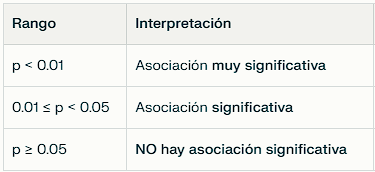

Ejemplo Práctico
Si p-valor = 0.0023, significa: "Si Género y Depresión fueran independientes, solo hay 0.23% de probabilidad de ver estos datos tan asociados. Eso es muy raro, así que probablemente NO son independientes, es decir, puede inferirse que existe una relacuión de dependencia entre esas dos variables."​

Si p-valor = 0.45, significa: "Hay 45% de probabilidad de ver estos datos si fueran independientes. Es bastante probable, así que se puede inferir que no hay mucha evidencia de asociación o dependencia."

El **estadístico χ²** es el valor numérico que resulta de aplicar la fórmula del test Chi-cuadrado. Cuantifica la diferencia acumulada entre frecuencias observadas y esperadas.

| Rango                  | Significado                                                   |
| ---------------------- | ------------------------------------------------------------- |
| χ² ≈ 0                 | Frecuencias observadas ≈ esperadas →Variables independientes  |
| χ² pequeño   | Diferencias leves entre observado/esperado → Asociación débil |
| χ² mediano | Diferencias moderadas → Asociación mediana                    |
| χ² grande   | Diferencias grandes →Asociación fuerte                        |

> Frecuencias observadas: son los conteos reales que se ve en cada celda de la tabla de contingencia. Ejemplo: en la celda “Deprimido = Sí” y “Género = Femenino” se tiene, digamos, 120 casos; ese 120 es una frecuencia observada.

> Frecuencias esperadas: son los conteos que se esperarían en cada celda si las variables fueran independientes.

> Se calculan con la fórmula:
Eij = ((total fila i)×(total columna j)) / Total general

> Es decir, se combinan las proporciones marginales de fila y columna: “si no hubiera asociación, ¿cuántos casos debería haber en esta celda solo por azar?”.

El estadístico χ² compara, celda a celda, cuánto se alejan las frecuencias observadas de las esperadas; cuanto mayor es esa discrepancia acumulada, más evidencia de asociación.


Relación con p-valor:

χ² grande → p-valor pequeño → Asociación significativa​

χ² pequeño → p-valor grande → Sin asociación significativa


Los **grados de libertad (df)** representan el número de valores que pueden variar libremente en un análisis estadístico, una vez que se han impuesto ciertas restricciones.​​

Dicho de otra forma: "¿Cuánta información 'nueva' tengo después de aplicar restricciones?"

Los grados de libertad conectan el estadístico calculado con la distribución teórica, permitiendo obtener un p-valor y tomar una decisión estadística.

Los **residuos estandarizados** son valores numéricos que miden cuánto se desvía cada celda de una tabla de contingencia respecto a lo que esperaríamos si las variables fueran completamente independientes.​

Es decir: responden a la pregunta "¿Esta celda tiene más o menos casos de lo que deberíamos esperar?"

Los residuos estandarizados permiten identificar exactamente cuáles celdas contribuyen más a la asociación Chi-cuadrado.


| Residuo       | Rango             | Interpretación                                           | ¿Contribuye?                     |
| ------------- | ----------------- | -------------------------------------------------------- | -------------------------------- |
| Entre -2 y +2 | Normal            | Celda se comporta como lo esperado si fueran independientes | NO contribuye significativamente |
| -3 a -2       | Moderado negativo | Hay MENOS casos que lo esperado (inversión moderada)        | SÍ, contribuye moderadamente     |
| +2 a +3       | Moderado positivo | Hay MÁS casos que lo esperado (asociación moderada)         | SÍ, contribuye moderadamente     |
| < -3          | Extremo negativo  | Hay MUCHO MENOS que lo esperado (inversión fuerte)          | SÍ, contribuye MUCHO             |
| > +3          | Extremo positivo  | Hay MUCHO MÁS que lo esperado (asociación fuerte)           | SÍ, contribuye MUCHO             |


¿Cuál es el "Valor Ideal"?

NO existe un único "valor ideal", depende de la pregunta:​

Si se quieren variables independientes: Residuos cercanos a 0 en todas las celdas​

Si se quiere identificar asociaciones: Residuos con valores |residuo| > 2 (esos indican patrones)

**V de Cramér** es una medida estandarizada que cuantifica la fuerza o magnitud de la asociación entre dos variables categóricas, independientemente del tamaño de la muestra.

¿Por qué es necesario?

El p-valor depende del tamaño de la muestra:

* Con muestras grandes, incluso asociaciones débiles pueden ser significativas (p < 0.05)​

* Con muestras pequeñas, asociaciones fuertes pueden no ser significativas​

V de Cramér es independiente del tamaño de muestra, así que te dice la verdadera fortaleza de la relación.

| V de Cramér | Tamaño del Efecto | Fortaleza de Asociación          | Ejemplo                              |
| ----------- | ----------------- | -------------------------------- | ------------------------------------ |
| 0.0 - 0.1   | Negligible        | Prácticamente ninguna relación   | Género y Color favorito              |
| 0.1 - 0.3   | Pequeño           | Asociación débil pero detectable | Género y Depresión (en muchos casos) |
| 0.3 - 0.5   | Mediano           | Asociación moderada y notable    | Ciudad y Prevalencia de Depresión    |
| > 0.5       | Grande            | Asociación fuerte y evidente     | Sexo y Género (correlación lógica)   |

Condiciones para calcular el Chi-Cuadrado:

* Variables categóricas: Ambas deben ser cualitativas (nominales u ordinales)​

* Muestra aleatoria: Datos recolectados aleatoriamente​

* Frecuencias esperadas ≥ 5 en cada celda de la tabla.

* Independencia de observaciones: Cada individuo contabilizado una sola vez​

In [ ]:
from scipy.stats import chi2_contingency

# 1. CREAR TABLA DE CONTINGENCIA
# Género vs. Depresión
contingency_table = pd.crosstab(df['Género'], df['Depresión'])
print("Tabla de Contingencia (Frecuencias Observadas):")
print(contingency_table)

Tabla de Contingencia (Frecuencias Observadas):
Depresión     0     1
Género               
Femenino   5128  7215
Masculino  6426  9111


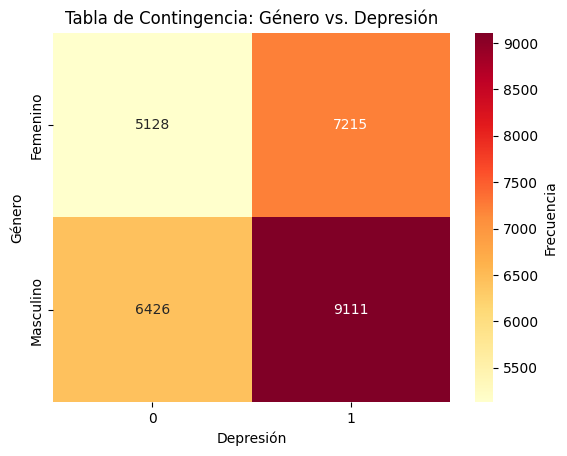

In [ ]:
# 2. VISUALIZAR LA TABLA
sns.heatmap(contingency_table, annot=True, fmt='d', cmap='YlOrRd',
            cbar_kws={'label': 'Frecuencia'})
plt.title('Tabla de Contingencia: Género vs. Depresión')
plt.ylabel('Género')
plt.xlabel('Depresión')
plt.show()

In [ ]:
# 3. REALIZAR TEST CHI-CUADRADO
chi2_stat, p_valor, df, expected_freq = chi2_contingency(contingency_table)

print("=" * 60)
print("RESULTADOS DEL TEST CHI-CUADRADO")
print("=" * 60)
print(f"Chi-cuadrado (χ²): {chi2_stat:.4f}")
print(f"p-valor: {p_valor:.6f}")
print(f"Grados de libertad (df): {df}")
print()

RESULTADOS DEL TEST CHI-CUADRADO
Chi-cuadrado (χ²): 0.0910
p-valor: 0.762869
Grados de libertad (df): 1



In [ ]:
# 4. INTERPRETAR RESULTADOS
print("INTERPRETACIÓN:")
if p_valor < 0.05:
    print(f"✓ SÍ existe asociación significativa (p = {p_valor:.6f} < 0.05)")
    print("  Las variables Género y Depresión NO son independientes")
else:
    print(f"✗ NO existe asociación significativa (p = {p_valor:.6f} ≥ 0.05)")
    print("  Las variables Género y Depresión son independientes")

# Se cumple que χ² pequeño → p-valor grande → Sin asociación significativa

INTERPRETACIÓN:
✗ NO existe asociación significativa (p = 0.762869 ≥ 0.05)
  Las variables Género y Depresión son independientes


In [ ]:
# 5. TABLA DE FRECUENCIAS ESPERADAS
print("Frecuencias Esperadas (si fueran independientes):")
expected_df = pd.DataFrame(expected_freq,
                          index=contingency_table.index,
                          columns=contingency_table.columns)
print(expected_df.round(2))

Frecuencias Esperadas (si fueran independientes):
Depresión        0        1
Género                     
Femenino   5115.17  7227.83
Masculino  6438.83  9098.17


In [ ]:
# 6. RESIDUOS ESTANDARIZADOS (qué celdas contribuyen más)
print("Residuos Estandarizados:")
residuals = (contingency_table - expected_df) / np.sqrt(expected_df)
print(residuals.round(3))
print("→ Valores > 2 o < -2 indican celdas que contribuyen significativamente")

Residuos Estandarizados:
Depresión      0      1
Género                 
Femenino   0.179 -0.151
Masculino -0.160  0.134
→ Valores > 2 o < -2 indican celdas que contribuyen significativamente


In [ ]:
# 7. TAMAÑO DEL EFECTO (V de Cramér)
# contingency_table.sum() suma los valores de cada columna y luego,
# el segundo .sum() suma esos subtotales para obtener el número total de observaciones en la tabla
n = contingency_table.sum().sum()
n

np.int64(27880)

In [ ]:
# Se determina los 'grados de libertad efectivos' para el cálculo de la V de Cramér
min_dim = min(contingency_table.shape[0] - 1, contingency_table.shape[1] - 1)
min_dim

1

In [ ]:
# Cálculo del V de Cramér
cramers_v = np.sqrt(chi2_stat / (n * min_dim))

print(f"V de Cramér (Tamaño del Efecto): {cramers_v:.4f}")
if cramers_v < 0.1:
    print("  → Efecto negligible (Prácticamente ninguna relación)")
elif cramers_v < 0.3:
    print("  → Efecto pequeño (Asociación débil pero detectable)")
elif cramers_v < 0.5:
    print("  → Efecto mediano (Asociación moderada y notable)")
else:
    print("  → Efecto grande (Asociación fuerte y evidente)")

V de Cramér (Tamaño del Efecto): 0.0018
  → Efecto negligible (Prácticamente ninguna relación)


In [ ]:
# RESUMEN FINAL
print("=" * 60)
print("CONCLUSIÓN")
print("=" * 60)
print(f"Hipótesis Nula (H₀): Género y Depresión son INDEPENDIENTES")
print(f"Hipótesis Alternativa (H₁): Género y Depresión NO son independientes")
print()
if p_valor < 0.05:
    print(f"DECISIÓN: Rechazamos H₀ (p = {p_valor:.6f})")
    print(f"Conclusión: Existe una asociación estadísticamente significativa")
    print(f"entre Género y Depresión (χ² = {chi2_stat:.4f}, df = {df})")
else:
    print(f"DECISIÓN: Aceptamos H₀ (p = {p_valor:.6f})")
    print(f"Conclusión: NO existe asociación significativa entre las variables")

In [ ]:
import numpy as np

# Pensamientos Suicidas vs. Depresión
contingency_table2 = pd.crosstab(df['PS'], df['Depresión'])
chi2_stat, p_valor, dof, expected_freq = chi2_contingency(contingency_table2) # Renamed df to dof

print("=" * 60)
print("RESULTADOS DEL TEST CHI-CUADRADO")
print("=" * 60)
print(f"Chi-cuadrado (χ²): {chi2_stat:.4f}")
print(f"p-valor: {p_valor:.6f}")
print(f"Grados de libertad (df): {dof}") # Used dof here
print()
print("Frecuencias Esperadas (si fueran independientes):")
expected_df = pd.DataFrame(expected_freq,
                          index=contingency_table2.index, # Changed contingency_table to contingency_table2
                          columns=contingency_table2.columns) # Changed contingency_table to contingency_table2
print(expected_df.round(2))
print("Residuos Estandarizados:")
residuals = (contingency_table2 - expected_df) / np.sqrt(expected_df) # Changed contingency_table to contingency_table2
print(residuals.round(3))

TypeError: 'int' object is not subscriptable



---



---


# **Visualizaciones: Matplotlib y Seaborn**

### **GRÁFICOS DE COMPARACIÓN**

### **Gráfico de Barras (Para Medias o Medianas)**

In [ ]:
# Matplotlib
variables = df[['Edad','Promedio Calificaciones Acumulativo','Horas de Trabajo']]
medias = variables.mean()

plt.bar(
    variables.columns,
    medias,
    color='blue',
    width=0.6,
    edgecolor='black',
    label='Variables'
)
plt.title('Comparación de Medias')
plt.xlabel('Variables')
plt.ylabel('Media')
plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
plt.xticks(rotation=45)   # Rotas las etiquetas
plt.grid(axis='y', linestyle='--', alpha=0.8)
plt.show()

En **Seaborn**, el dataframe debe estar en "formato largo", para lo cual se utiliza el método **.melt()**, que convierte un dataframe de este tipo:

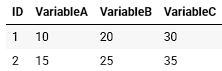

a uno de este tipo:

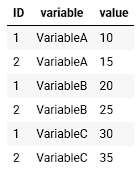

**.melt()** tiene los siguiente parámetros:

*  **Columnas identificadoras (id_vars):**
  *  Columnas que quieres mantener como están. En el ejemplo anterior, podría ser 'ID'.
*  **Columnas a "derretir" (value_vars):**
  *  Columnas que quieres apilar en una sola columna. En el ejemplo, serían 'VariableA', 'VariableB', 'VariableC'.
*  **Nombre de la nueva columna para los nombres de las variables derretidas (var_name):**
  *  Un nombre que le das a la columna que contendrá los nombres de las variables originales ('VariableA', 'VariableB', 'VariableC'). Por defecto, se llama 'variable'.
*  **Nombre de la nueva columna para los valores de las variables derretidas (value_name):**
  *  Un nombre que le das a la columna que contendrá los valores correspondientes (10, 20, 30, 15, 25, 35). Por defecto, se llama 'value'.

In [ ]:
# Seaborn

nuevodf = variables.melt(var_name='variable', value_name='value') # Convertir a formato largo

sns.barplot(
    data=nuevodf,
    x='variable',
    y='value',
    hue=None,
    estimator='mean',       # 'median', 'sum', etc.
    errorbar=('ci', 95),    # Intervalo de confianza (None para omitir)
    capsize=0.1             # Tamaño de las líneas de error
)
plt.title('Medias con Intervalo de Confianza')
plt.xticks(rotation=45)  # Rotas las etiquetas
plt.show()

### **GRÁFICOS DE RELACIÓN**

### **Gráfico de Dispersión (Scatter Plot)**

**Propósito:** Un gráfico de dispersión (o scatter plot) es una herramienta fundamental para visualizar la relación entre dos variables numéricas. Permite identificar patrones, tendencias, correlaciones y valores atípicos en los datos.

**Sirve para:**
*  **Identificar relaciones entre variables:**
  *  ¿Aumenta una variable cuando la otra aumenta? (Correlación positiva)
  *  ¿Disminuye una variable cuando la otra aumenta? (Correlación negativa)
  *  ¿No hay un patrón claro? (Correlación débil o nula)
*  **Detectar valores atípicos (outliers):**
  *  Puntos que se alejan mucho de la tendencia general.
*  **Visualizar agrupamientos (clusters):**
  *  Grupos naturales de datos que pueden indicar categorías no definidas previamente.
*  **Evaluar la fuerza de una correlación:**
  *  Mientras más cerca estén los puntos de una línea imaginaria, más fuerte es la relación.
*  **Analizar patrones no lineales:**
  *  Relaciones cuadráticas, exponenciales o logarítmicas.

**Interpretación:**
*  **Ejes del gráfico**
  *  **Eje X (horizontal):** Variable independiente.
  *  **Eje Y (vertical):** Variable dependiente.
*  **Posición y distribución de los puntos**
  *  **Correlación positiva (↑↑):** Los puntos tienden a subir de izquierda a derecha.
  *  **Correlación negativa (↑↓):** Los puntos bajan de izquierda a derecha.
  *  **Correlación débil o nula (sin patrón):** Los puntos están dispersos sin tendencia clara.
*  **Agrupamientos (clusters)**
  *  Si los puntos forman grupos separados, puede indicar subcategorías en los datos.
*  **Valores atípicos (outliers)**
  *  Puntos que están lejos de la tendencia principal.
*  **Intensidad de la relación**
  *  **Correlación fuerte:** Los puntos están muy cerca de una línea imaginaria.
  *  **Correlación moderada:** Dispersión media alrededor de la tendencia.
  *  **Correlación débil:** Los puntos están muy esparcidos.

In [ ]:
# Matplotlib

from matplotlib.lines import Line2D

plt.figure(figsize=(5, 4))                    # Tamaño del gráfico
plt.scatter(
    df['Promedio Calificaciones Acumulativo'],
    df['Horas de Trabajo'],
    c='red',                                  # Color (puede ser un array de colores)
    s=df['DS']*20,   # Tamaño basado en otra variable (multiplicado por factor)
    alpha=0.6,
    #label='Datos académicos',                 # Esto aparecerá en .legend(), en cuyo caso se usa sin el 'handles'
    marker='o',
    edgecolor='black',                        # Borde de los puntos
    linewidth=0.5                             # Grosor del borde
)
plt.title('Relación entre la Promedio Calificaciones Acumulativo y la Horas de Trabajo', pad=20)
plt.xlabel('Promedio Calificaciones Acumulativo', labelpad=10)
plt.ylabel('Horas de Trabajo', labelpad=10)
plt.xlim(-1, 11)
plt.ylim(-1, 11)
plt.grid(alpha=0.3)

# Crear elementos de leyenda manualmente, en cuyo caso no se usa el 'label'
legend_elements = [ Line2D([0], [0], marker='o', color='w', label='Datos académicos',
                    markerfacecolor='red', markersize=10) ]
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0, handles=legend_elements)  # Leyenda fuera del gráfico (handles=legend_elements)

#plt.colorbar(label='Escala de color')  # Si usas colores numéricos
plt.show()

In [ ]:
# Seaborn
plt.figure(figsize=(8, 5))                # Tamaño del gráfico
sns.scatterplot(
    data=df,
    x='Promedio Calificaciones Acumulativo',
    y='Horas de Trabajo',
    #hue='Horas de Trabajo',             # Color por variable categórica o numérica
    size='Promedio Calificaciones Acumulativo',   # Tamaño por otra variable
    sizes=(0, 100),                      # Rango de tamaños (min, max)
    #palette='viridis',                   # Paleta de colores
    alpha=0.7,
    edgecolor='black',
    linewidth=0.5
)
plt.title('Relación entre la Promedio Calificaciones Acumulativo y la Horas de Trabajo', fontsize=10, pad=20)
plt.xlabel('Promedio Calificaciones Acumulativo', fontsize=10)
plt.ylabel('Horas de Trabajo', fontsize=10)
plt.xlim(-1, 11)
plt.ylim(-1, 11)
plt.legend(title='Promedio Calificaciones Acumulativo', bbox_to_anchor=(1, 1), loc='upper left')  # Leyenda fuera del gráfico
plt.grid(alpha=0.2)
plt.tight_layout()     # Ajuste automático de márgenes
plt.show()

### **Gráfico Hexbin (Hexagonal Binning)**

**Propósito:** Un gráfico Hexbin es una visualización que representa la densidad de puntos en un espacio bidimensional usando hexágonos, donde el color o tamaño de cada hexágono indica la cantidad de puntos que caen en esa zona. Es ideal para conjuntos de datos grandes donde un scatter plot tradicional sería ilegible por superposición de puntos.

**Sirve para:**
*  **Visualizar densidad de datos:** Muestra concentraciones en lugar de puntos individuales.
*  **Identificar patrones:** Revela relaciones, clusters o vacíos en datos masivos.
*  **Evitar el "overplotting":** Problema común en scatter plots con miles/millones de puntos.
*  **Analizar distribuciones bivariadas:** Cómo se relacionan dos variables numéricas.

**Interpretación:**
*  **Densidad de datos**
  *  **Áreas cálidas (rojos/amarillos):** Zonas con muchos puntos (alta densidad).
  *  **Áreas frías (azules/verdes):** Zonas con pocos puntos (baja densidad).
  *  **Hexágonos vacíos:** Regiones sin datos.
*  **Patrones**
  *  **Clusters:** Grupos de hexágonos con alta densidad.
  *  **Correlación:** Si los hexágonos forman una línea diagonal, sugiere relación lineal.
  *  **Vacíos:** Áreas sin datos.
*  **Comparación con scatter plot**
  *  **Ventaja:** Hexbin muestra estructura oculta en datos masivos.
  *  **Desventaja:** Oculta valores atípicos individuales.

**NO usarlo:**
*  **Datos categóricos:** Usa gráficos de barras o boxplots.
*  **Conjuntos pequeños (<1,000 puntos):** Un scatter plot es más informativo.
*  **Necesidad de ver puntos individuales:** Hexbin agrupa datos.

In [ ]:
plt.figure(figsize=(5, 4))   # Tamaño del gráfico
plt.hexbin(
    df['Satisfacción con el Estudio'],
    df['Presión Académica'],
    gridsize=7,             # Número de hexágonos en el eje X
    cmap='inferno',          # Mapa de colores
    edgecolor='none',       # Sin bordes en los hexágonos: none o color si tiene borde
    bins=5,              # 'log': Escala logarítmica para los colores, 'linear': Escala lineal, int: enteros
    mincnt=1,                 # Mínimo de puntos para mostrar un hexágono
    vmin=0,                 # Establece el valor mínimo para la barra de colores
    vmax=5                # Establece el valor máximo para la barra de colores
)

plt.colorbar(label='Nivel')  # Barra de colores
plt.title('Relación entre la Satisfacción con el Estudio y la Presión Académica')
plt.xlabel('Variable X')
plt.ylabel('Variable Y')
plt.show()

### **Mapa de Calor (Heatmap)**

**Propósito:** Un heatmap es una representación gráfica de datos matriciales donde los valores individuales se visualizan con colores. Es especialmente útil para identificar patrones, correlaciones y variaciones en conjuntos de datos complejos.

**Sirve para:**
*  **Identificar correlaciones:** Entre variables numéricas.
*  **Detectar patrones:** En datos espaciales o temporales.
*  **Visualizar distribuciones:** De valores en una matriz.
*  **Comparar categorías:** Rendimiento por grupos.
*  **Resaltar valores atípicos:** Puntos con colores extremos.

**Interpretación:**
*  **Lee la escala de colores**
  *  Colores cálidos (rojos, naranjas): Valores altos.
  *  Colores fríos (azules, verdes): Valores bajos.
  *  Blancos/grises: Valores intermedios (en algunas paletas).
*  **Busca patrones visuales**
  *  **Agrupamientos (clusters):** Bloques de colores similares (ej: genes con expresión similar).
  *  **Filas/columnas uniformes:** Indica poca variabilidad.
  *  **Filas/columnas con variación:** Señala cambios importantes.
*  **Analiza correlaciones (si es una matriz de correlación)**
  *  **Valores cercanos a 1:** Correlación positiva fuerte (mismo color).
  *  **Valores cercanos a -1:** Correlación negativa fuerte (colores opuestos).
  *  **Valores cercanos a 0:** No hay correlación (color neutro).
*  **Identifica valores extremos**
  *  Puntos con colores muy distintos al resto (outliers).

In [ ]:
# Se crea la matriz de datos a graficar
data = tab_contingencia
data

In [ ]:
print(f"Valor mínimo de data: {data.min().min()}")
# data.min() calcula el valor mínimo de cada columna en el DataFrame data.
#Esto devuelve una Serie. Luego, el segundo .min() se aplica a esta Serie
# para encontrar el valor mínimo de todos los mínimos de las columnas,
# es decir, el valor más pequeño de todo el DataFrame.

print(f"Valor máximo de data: {data.max().max()}")
# De manera similar, data.max() encuentra el valor máximo de cada columna,
# y luego el segundo .max() obtiene el valor más grande de entre todos esos
# máximos, resultando en el valor más grande de todo el DataFrame.

In [ ]:
# Matplotlib

plt.figure(figsize=(8, 6))    # Tamaño del gráfico (ancho, alto)

heatmap = plt.imshow(
    data,                     # Matriz de datos a visualizar
    cmap='coolwarm',          # Paleta de colores ('viridis', 'coolwarm', 'magma', 'plasma')
    interpolation='nearest',  # Método de interpolación ('nearest', 'bilinear')
    vmin=data.min().min(),                   # Valor mínimo para la escala de colores
    vmax=data.max().max(),                   # Valor máximo para la escala de colores
    aspect='auto'             # Aspecto de las celdas ('auto', 'equal', o un número)
)

plt.colorbar(label='Valores')                   # Añade barra de colores con etiqueta
plt.title('Correlaciones', pad=20)              # Título con padding
plt.xlabel('Columnas')                          # Etiqueta eje X
plt.ylabel('Filas')                             # Etiqueta eje Y

plt.xticks(
    np.arange(len(data.columns)),  # Posiciones en el eje X
    labels=data.columns,           # Etiquetas personalizadas
    rotation=90
)
plt.yticks(
    np.arange(len(data.index)),    # Posiciones en el eje Y
    labels=data.index              # Etiquetas personalizadas
)

plt.tight_layout()                 # Ajusta los márgenes
plt.show()

In [ ]:
# Seaborn

plt.figure(figsize=(8, 6))
sns.heatmap(
    data,
    annot=True,               # Mostrar valores en las celdas
    fmt='.2f',                # Formato de los valores 'd' / '.0f': enteros, '.1f': 1 decimal,
                              # '.2e': Notación científica con 2 decimales, '.1%': Porcentaje con 1 decimal, 's': Muestra los valores como strings
    cmap="magma_r",           # Mapa de colores
    vmin=data.min().min(),                   # Límites de la escala
    vmax=data.max().max(),
    linewidths=.5,            # Ancho de las líneas entre celdas
    cbar=True,                # Barra de colores
    cbar_kws={'label': 'Valores'}  # Personalizar barra de colores
)

plt.title('Correlaciones', pad=20)
plt.show()

### **GRÁFICOS DE TENDENCIA / TEMPORAL**

### **Gráfico de Línea (Line Plot)**

**Propósito:** Un gráfico de línea (o line plot) es una representación visual que conecta puntos de datos individuales con segmentos rectos, mostrando la evolución de una variable a lo largo de un eje continuo (como tiempo o distancia).

**Sirve para:**
*  Mostrar tendencias temporales.
*  Comparar múltiples series.
*  Identificar patrones: Estacionalidad, picos, valles o cambios abruptos.
*  Visualizar relaciones continuas.

**Partes clave de un gráfico de línea**
*  **Eje X (horizontal):** Variable independiente.
*  **Eje Y (vertical):** Variable dependiente.
*  **Líneas:** Conectan puntos de datos en orden secuencial.
*  **Marcadores:** Puntos que representan valores individuales (opcionales).
*  **Leyenda:** Explica series cuando hay múltiples líneas.
*  **Varias líneas:** Se colocan varios `.plot()` para un mismo `.show()`.

**Interpretación:**
*  **Dirección de la línea**
  *  **Ascendente:** Aumento en la variable Y al avanzar en X.
  *  **Descendente:** Disminución en Y.
  *  **Estable:** Sin cambios significativos.
*  **Pendiente (inclinación)**
  *  **Pendiente pronunciada:** Cambio rápido.
  *  **Pendiente suave:** Cambio gradual.
*  **Patrones recurrentes**
  *  **Estacionalidad:** Repetición de patrones en intervalos regulares.
  *  **Ciclos:** Fluctuaciones no periódicas.
*  **Puntos clave**
  *  **Máximos y mínimos:** Identificar valores pico o valles.
  * **Puntos de inflexión:** Donde la tendencia cambia.
*  **Comparación entre líneas**
  *  **Cruces:** Cuando una serie supera a otra.
  *  **Divergencias:** Diferencias crecientes/reductivas entre series.

**Errores comunes:**
*  **Eje X no ordenado:** Si los datos no son secuenciales, la línea engaña.
*  **Demasiadas líneas:** >5 series dificultan la lectura (usar facetas o interactividad).
*  **Escalas inapropiadas**.

**NO usarlo:**
*  Datos categóricos no ordenados (mejor: gráfico de barras).
*  Muy pocos puntos (<4, mejor: diagrama de puntos).
*  Variables discretas.

In [ ]:
# Matplotlib

Año = [2010, 2011, 2012, 2013, 2014, 2015, 2016]
Ventas_A = [120, 145, 160, 175, 190, 210, 230]
Ventas_B = [80, 110, 130, 150, 170, 200, 220]

plt.figure(figsize=(6, 4))  # Tamaño del gráfico

plt.plot(
    Año,                     # x
    Ventas_A,                # y
    color='purple',          # Color de la línea
    linestyle='--',          # Estilo de línea ('-', '--', ':', '-.')
    linewidth=2,             # Ancho de la línea
    marker='o',              # Marcadores (ej: 'o', 's', '^')
    markersize=5,            # Tamaño de los marcadores
    label='Ventas A'         # Etiqueta para la leyenda
)

plt.plot(
    Año,                     # x
    Ventas_B,                # y
    color='green',          # Color de la línea
    linestyle=':',          # Estilo de línea ('-', '--', ':', '-.')
    linewidth=2,             # Ancho de la línea
    marker='o',              # Marcadores (ej: 'o', 's', '^')
    markersize=5,            # Tamaño de los marcadores
    label='Ventas B'         # Etiqueta para la leyenda
)

plt.title('Evolución de las Ventas')
plt.xlabel('Año')
plt.ylabel('Ventas (unidades)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# Seaborn

data = pd.DataFrame({
    'Año': [2010, 2011, 2012, 2013, 2014, 2015, 2016],
    'Ventas_A': [120, 145, 160, 175, 190, 210, 230],
    'Ventas_B': [80, 110, 130, 150, 170, 200, 220]
})

plt.figure(figsize=(6, 4))  # Tamaño del gráfico

sns.lineplot(
    data=data,                # DataFrame de entrada
    x='Año',                 # Variable para el eje X (debe ser numérica o categórica ordenada)
    y='Ventas_A',            # Variable para el eje Y
    #hue='',                # Opcional: Color por variable (útil para múltiples líneas)
    #style='',              # Opcional: Estilo de línea por variable
    markers=True,            # Mostrar marcadores en los puntos de datos
    dashes=True,            # Líneas sólidas (sin segmentos)
    #palette='viridis',       # Mapa de colores si hue está activo
    linewidth=2.5,           # Grosor de la línea
    marker='o',              # Tipo de marcador ('o', 's', 'D', etc.)
    markersize=8,            # Tamaño de los marcadores
    alpha=0.8,              # Transparencia (0 a 1)
    estimator=None,       # Función para agregar datos 'mean', 'median', None para datos crudos)
    errorbar='sd',                # Intervalo de confianza: 'sd': Desviación estándar, 95:Intervalo del 95%, None:Sin sombreado
    legend='auto'           # Leyenda automática
)

sns.lineplot(
    data=data,                # DataFrame de entrada
    x='Año',                 # Variable para el eje X (debe ser numérica o categórica ordenada)
    y='Ventas_B',            # Variable para el eje Y
    #hue='',                # Opcional: Color por variable (útil para múltiples líneas)
    #style='',              # Opcional: Estilo de línea por variable
    markers=True,            # Mostrar marcadores en los puntos de datos
    dashes=True,            # Líneas sólidas (sin segmentos)
    #palette='viridis',       # Mapa de colores si hue está activo
    linewidth=2.5,           # Grosor de la línea
    marker='o',              # Tipo de marcador ('o', 's', 'D', etc.)
    markersize=8,            # Tamaño de los marcadores
    alpha=0.8,              # Transparencia (0 a 1)
    estimator=None,       # Función para agregar datos 'mean', 'median', None para datos crudos)
    errorbar='sd',                # Intervalo de confianza: 'sd': Desviación estándar, 95:Intervalo del 95%, None:Sin sombreado
    legend='auto'           # Leyenda automática
)

plt.title('Evolución de las Ventas', fontsize=14)
plt.xlabel('Año', fontsize=12)
plt.ylabel('Ventas (unidades)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)
sns.despine()  # Eliminar bordes superfluos

plt.tight_layout()
plt.show()

### **Gráfico de Área (Area Plot)**

**Propósito:** Un gráfico de área es una variante del gráfico de línea donde el espacio entre la línea y el eje X se rellena con color. Es especialmente útil para mostrar la magnitud y composición de los datos a lo largo de una dimensión continua (como el tiempo).

**Sirve para:**
*  **Visualizar tendencias temporales:** Mostrar cambios en valores acumulativos.
*  **Comparar proporciones:** Ver cómo contribuyen partes a un total.
*  **Identificar patrones**: Estacionalidad, crecimiento o declive en múltiples categorías.
*  **Destacar acumulación:** Cuando el enfoque está en el volumen total, no solo en la tendencia.

**Interpretación:**
*  **Para gráficos de área simple**
*  **Altura del área:** Indica la magnitud del valor en cada punto.
*  **Pendiente:**
  *  **Ascendente** = Aumento en la variable.
  *  **Descendente** = Disminución.
*  **Área total bajo la curva:** Representa la acumulación total.

**Errores comunes:**
*  **Usar demasiadas categorías:** >5 series apiladas dificultan la lectura.
*  **Ignorar el orden de apilamiento:** Coloca las series más estables en la base.
*  **Olvidar la transparencia:** En áreas no apiladas, sin alpha se ocultan datos.

**NO usarlo**
*  Datos discretos o categóricos (mejor: gráfico de barras).
*  Comparar valores absolutos (no apilados) con escalas muy distintas.
*  Cuando hay valores negativos (puede confundir en áreas apiladas).

Seaborn no tiene una función nativa para gráficos de área

In [ ]:
data = pd.DataFrame({
    'Año': [2010, 2011, 2012, 2013, 2014, 2015, 2016],
    'Ventas_A': [120, 145, 160, 175, 190, 210, 230],
    'Ventas_B': [80, 110, 130, 150, 170, 200, 220]
})

plt.figure(figsize=(8, 5))

plt.fill_between(
    data['Año'],
    data['Ventas_A'],
    color='blue',         # Color del área
    alpha=0.3,               # Transparencia (0 a 1)
    label='Área bajo y1'
)
plt.plot(data['Año'], data['Ventas_A'], color='blue', label='y1')

plt.legend()
plt.title('Gráfico de Área de Ventas')
plt.xlabel('Año')
plt.ylabel('Ventas (unidades)')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# gráficos de área apilada

data.set_index('Año').plot.area(
    stacked=True,
    color=['green', 'blue'],
    alpha=0.3
)

plt.legend()
plt.title('Ventas apiladas por producto')
plt.ylabel('Ventas (unidades)')
plt.show()

In [ ]:
# gráficos de área no apilada
plt.fill_between(data['Año'], data['Ventas_A'], color='green', alpha=0.3, label='A')
#plt.plot(data['Año'], data['Ventas_A'], color='green', label='y1')
plt.fill_between(data['Año'], data['Ventas_B'], color='blue', alpha=0.3, label='B')
#plt.plot(data['Año'], data['Ventas_B'], color='blue', label='y2')

plt.legend()
plt.title('Ventas no apiladas por producto')
plt.ylabel('Ventas (unidades)')
plt.show()